# Notebook Projet fil rouge b3 Maury Quentin, Quiatol Evan.

## Importation des données 

In [5]:
# connexion à la base dans le même dossier
import sqlite3

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

conn = sqlite3.connect("data/meteo_projet.db")

# lire une table
df = pd.read_sql_query("SELECT * FROM hourly_weather", conn)

# afficher le tableau
print(df)

                       date  temperature_2m  weather_code  wind_speed_10m  \
0       2009-12-31 23:00:00           1.104           3.0       14.145756   
1       2010-01-01 00:00:00           0.954           3.0       14.759999   
2       2010-01-01 01:00:00           0.754           3.0       16.520823   
3       2010-01-01 02:00:00           0.554           3.0       16.099689   
4       2010-01-01 03:00:00           0.454           3.0       15.391840   
...                     ...             ...           ...             ...   
141859  2026-03-08 18:00:00          14.100           0.0        2.885619   
141860  2026-03-08 19:00:00          13.050           0.0        2.577208   
141861  2026-03-08 20:00:00          12.050           0.0        2.545584   
141862  2026-03-08 21:00:00          11.200           0.0        3.640275   
141863  2026-03-08 22:00:00          10.550           0.0        3.784283   

        rain  snowfall  precipitation  wind_speed_100m  snow_depth  \
0    

### Verification des valeurs null 

In [6]:
df.isnull().sum()

date                         0
temperature_2m               0
weather_code                 0
wind_speed_10m               0
rain                         0
snowfall                     0
precipitation                0
wind_speed_100m              0
snow_depth                   0
apparent_temperature         0
relative_humidity_2m         0
cloud_cover                  0
wind_direction_10m           0
soil_temperature_0_to_7cm    0
surface_pressure             0
is_day                       0
sunshine_duration            0
dtype: int64

## Visualisation 

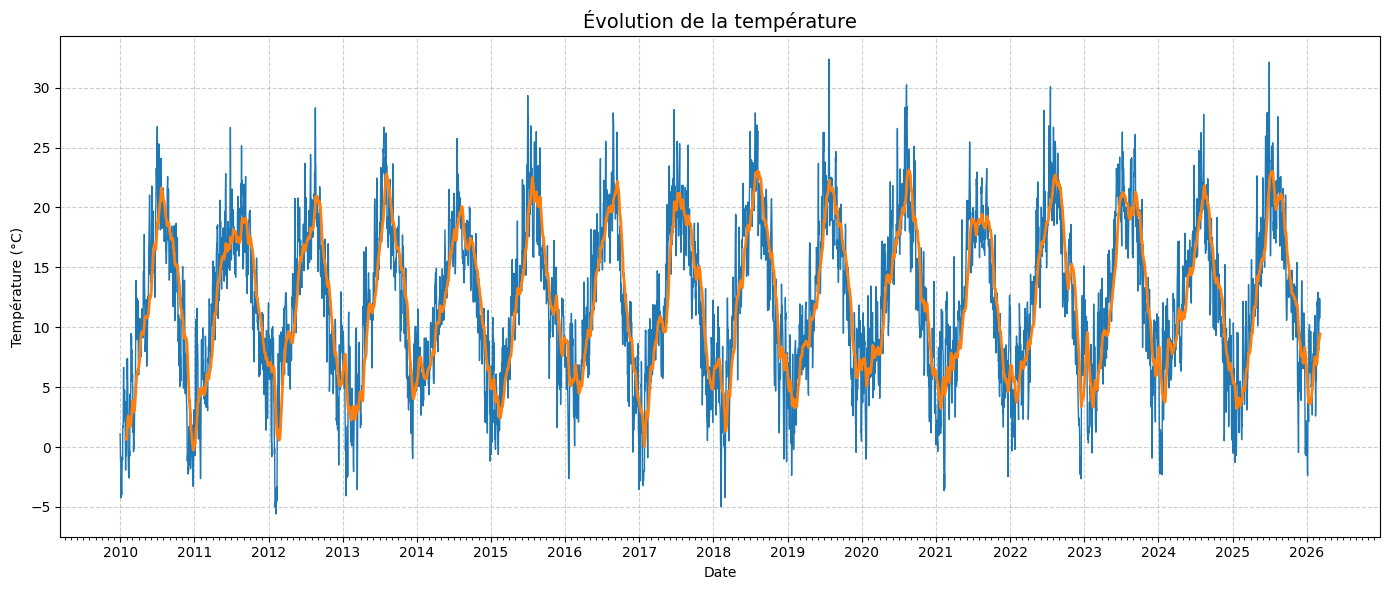

In [7]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# moyenne journalière pour réduire le bruit
df_daily = df.set_index('date').resample('D').mean()

plt.figure(figsize=(14,6))

plt.plot(
    df_daily.index,
    df_daily['temperature_2m'],
    linewidth=1
)

# moyenne glissante (30 jours)
rolling = df_daily['temperature_2m'].rolling(30).mean()
plt.plot(df_daily.index, rolling, linewidth=2)

plt.title("Évolution de la température", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Température (°C)")

# axe temporel lisible
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Le graphique ci-dessus n'est pas très lisible, donc nous allons prendre une range d'une semaine pour faire une meilleure visualisation de l'évolution de la température dans le temps.

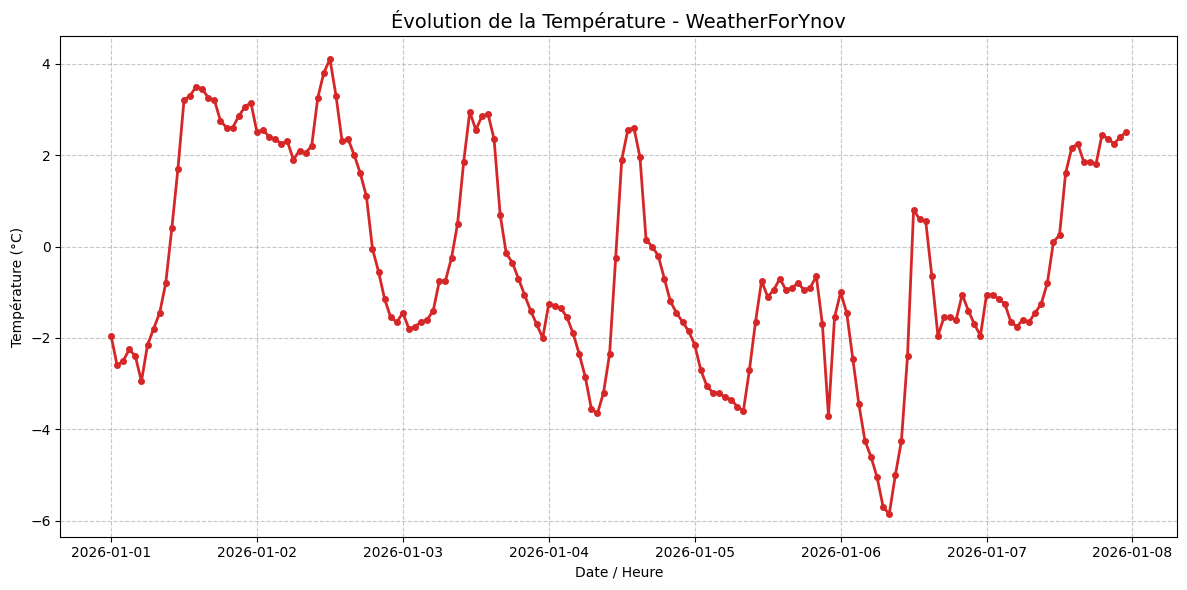

In [8]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

start_date = pd.Timestamp("2026-01-01 00:00:00")
end_date = pd.Timestamp("2026-01-07 23:00:00")

mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_filtered = df.loc[mask]

plt.figure(figsize=(12, 6))
plt.plot(
    df_filtered['date'],
    df_filtered['temperature_2m'],
    color='tab:red',
    linewidth=2,
    marker='o',
    markersize=4
)
plt.title('Évolution de la Température - WeatherForYnov', fontsize=14)
plt.xlabel('Date / Heure')
plt.ylabel('Température (°C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Nous pouvons observer qu'il y a une chute des températures pendant la nuit et qu'il y a une certaine continuité entre les jours.

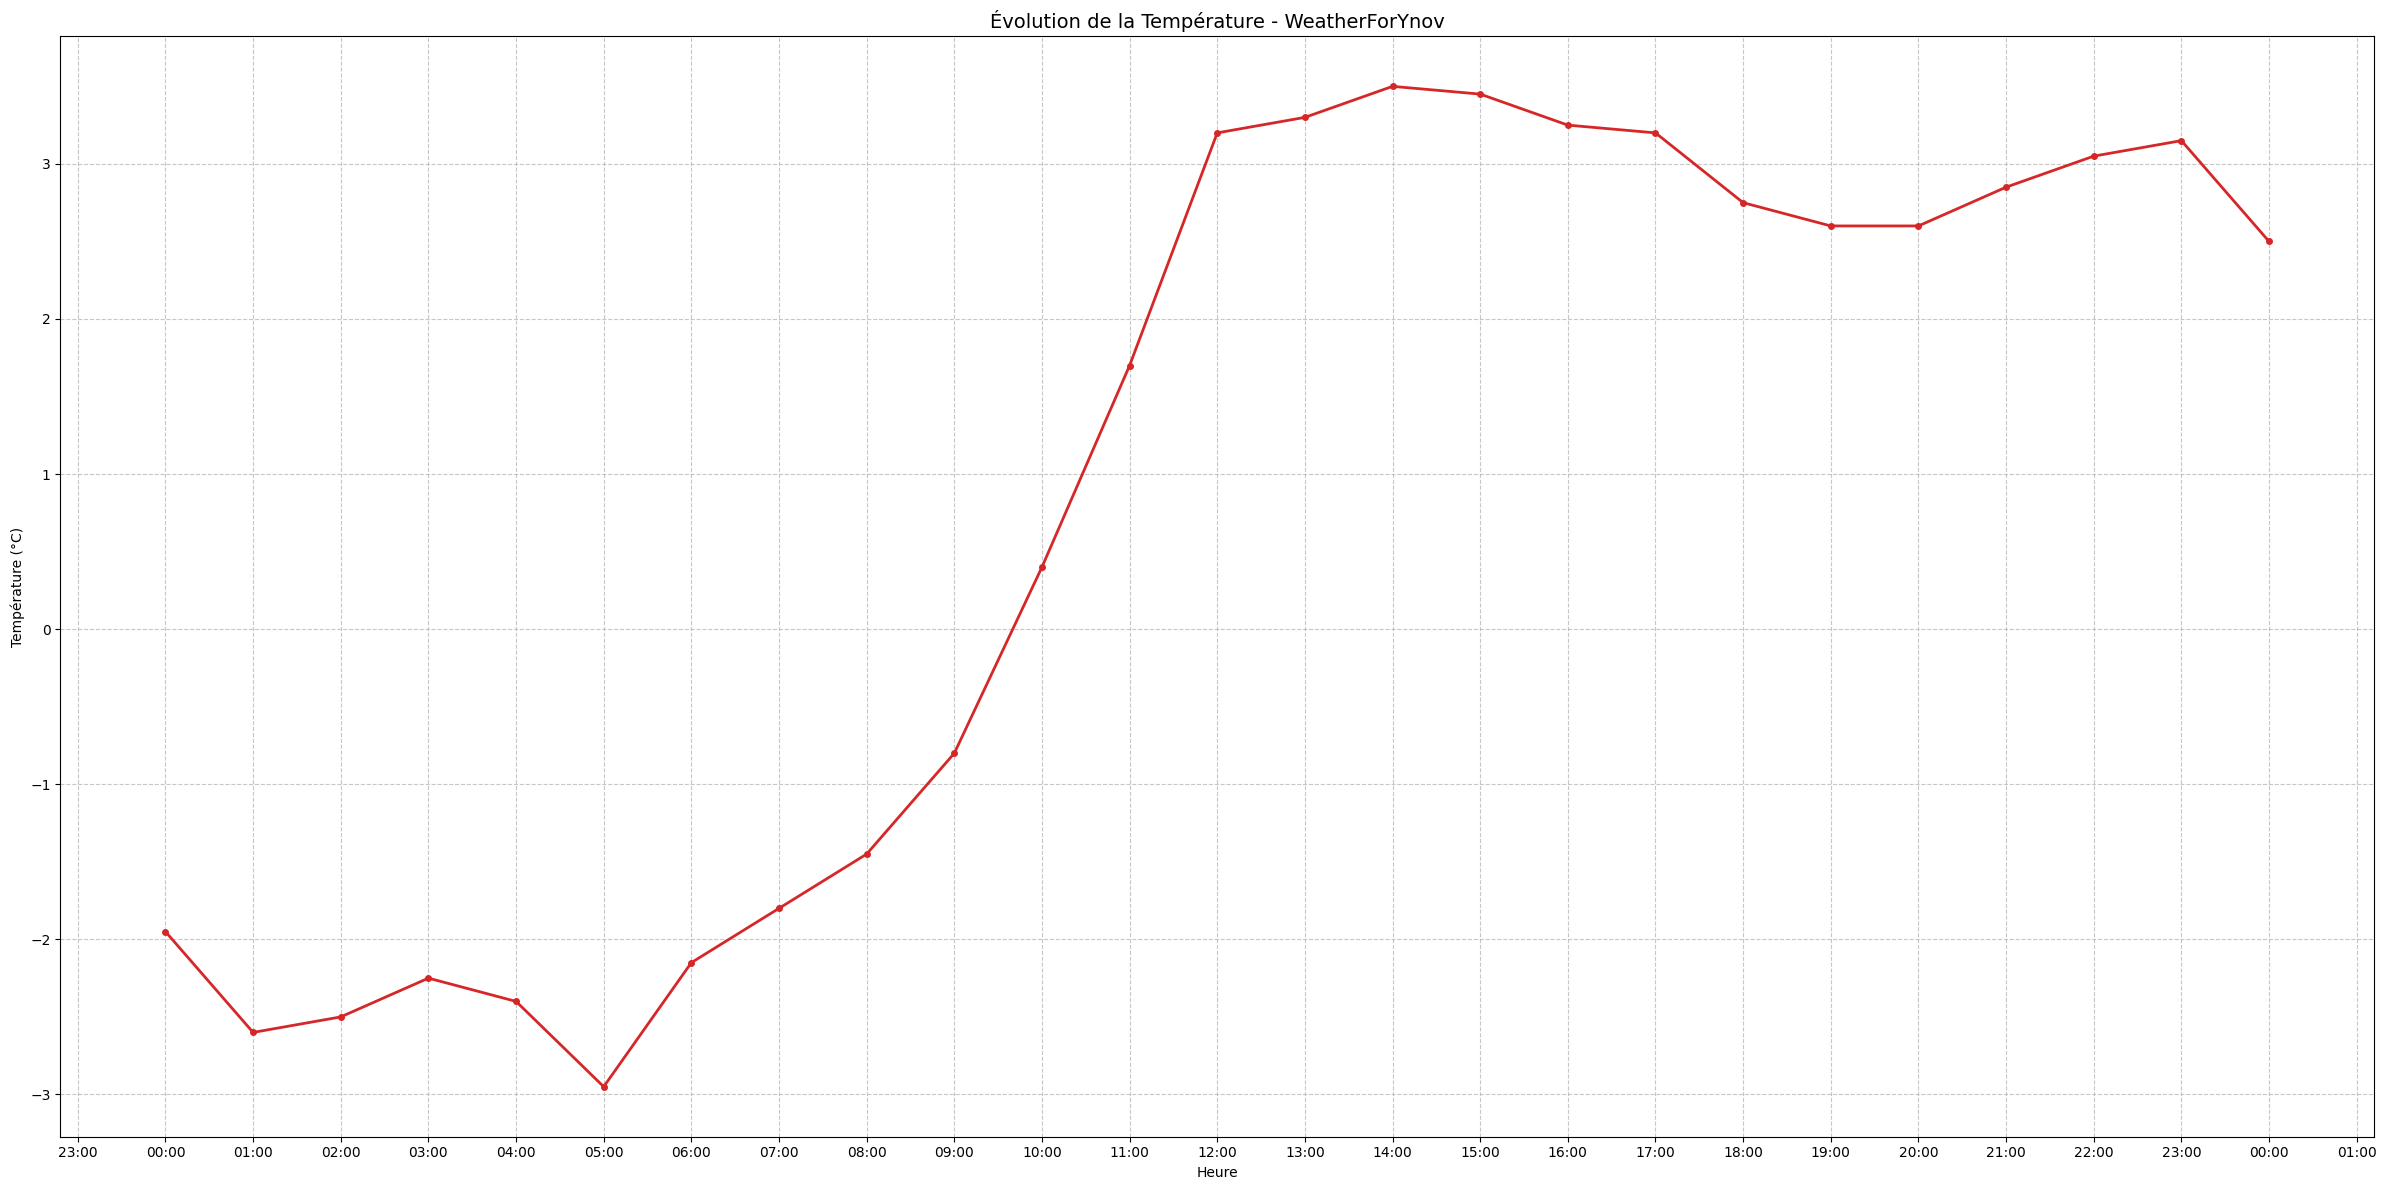

In [9]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

start_date = pd.Timestamp("2026-01-01 00:00:00")
end_date = pd.Timestamp("2026-01-02 00:00:00")

mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_filtered = df.loc[mask]

plt.figure(figsize=(24,12))
plt.plot(df_filtered['date'], df_filtered['temperature_2m'], color='tab:red', linewidth=2, marker='o', markersize=4)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))

plt.title('Évolution de la Température - WeatherForYnov', fontsize=14)
plt.xlabel('Heure')
plt.ylabel('Température (°C)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Ce graphique ici confirme que la température est plus basse la nuit.

In [10]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

start_date = "2026-01-01 00:00:00+00:00"
end_date = "2026-01-07 23:00:00+00:00"

mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_filtered = df.loc[mask]

plt.Figure(figsize=(12,6))
plt.plot(df_filtered['date'], df_filtered['wind_speed_10m'], color='tab:red', linewidth=2, marker='o', markersize=4)
plt.title('Évolution de la vitesse du vent - WeatherForYnov', fontsize=14)
plt.xlabel('Date / Heure')
plt.ylabel('Vitesse du vent (km/h)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

TypeError: Invalid comparison between dtype=datetime64[us] and str

On peut observer que la vitesse du vent est étroitement corrélé avec la température. Cependant, on ne peut pas affirmer à 100% qu'ils sont corrélées

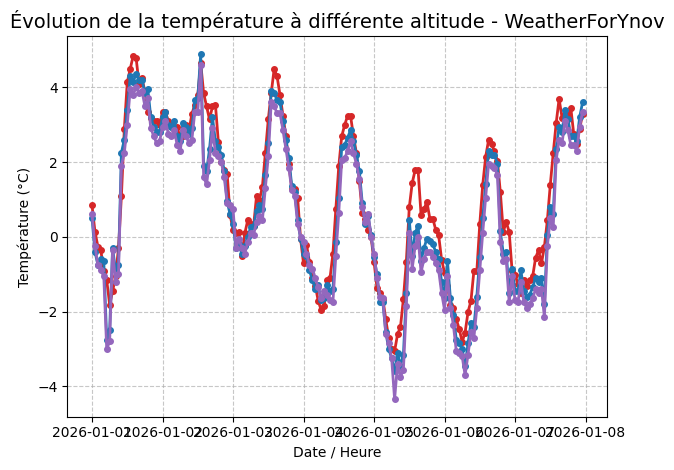

In [7]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

start_date = "2026-01-01 00:00:00+00:00"
end_date = "2026-01-07 23:00:00+00:00"

mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_filtered = df.loc[mask]

plt.Figure(figsize=(12,6))
plt.plot(df_filtered['date'], df_filtered['temperature_2m'], color='tab:red', linewidth=2, marker='o', markersize=4)
plt.plot(df_filtered['date'], df_filtered['temperature_20m'], color='tab:blue', linewidth=2, marker='o', markersize=4)
plt.plot(df_filtered['date'], df_filtered['temperature_50m'], color='tab:purple', linewidth=2, marker='o', markersize=4)
plt.title("Évolution de la température à différente altitude - WeatherForYnov", fontsize=14)
plt.xlabel('Date / Heure')
plt.ylabel('Température (°C)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

On peut remarquer que les températures à différentes altitudes semblent très liés

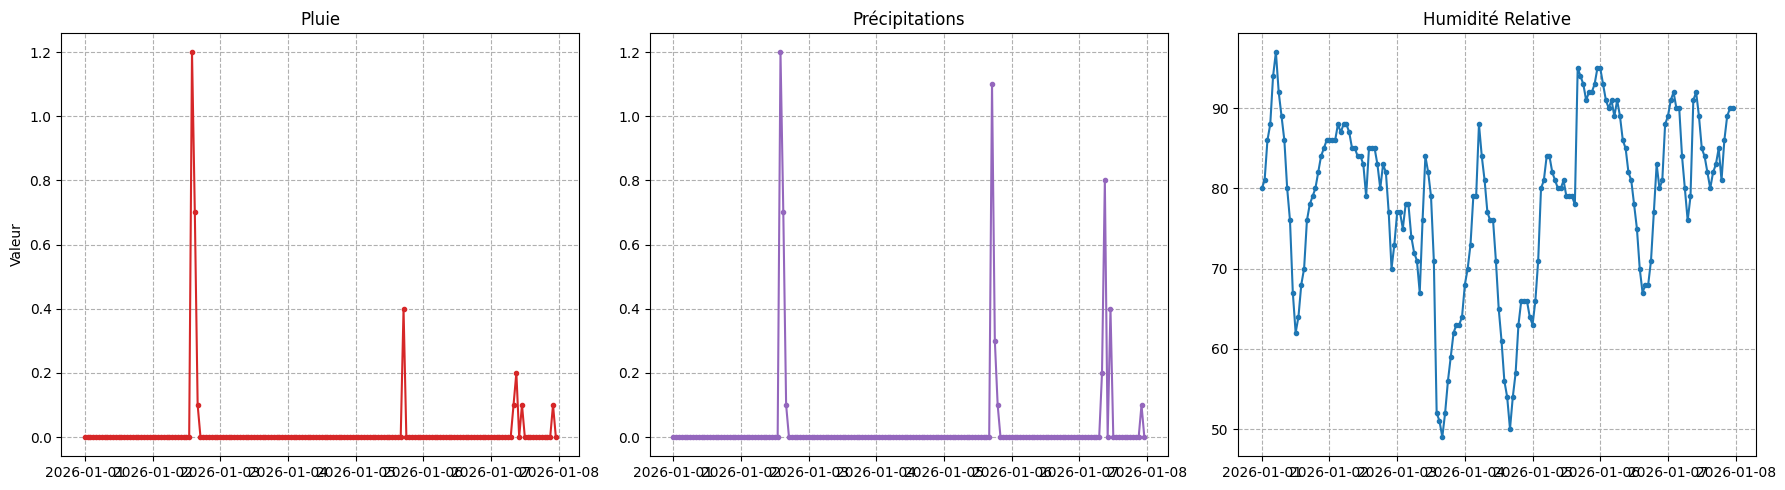

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Graphique 1 : Rain (Pluie)
ax1.plot(df_filtered['date'], df_filtered['rain'], color='tab:red', marker='o', markersize=3)
ax1.set_title('Pluie')
ax1.set_ylabel('Valeur')
ax1.grid(True, linestyle='--')

# Graphique 2 : Précipitations
ax2.plot(df_filtered['date'], df_filtered['precipitation'], color='tab:purple', marker='o', markersize=3)
ax2.set_title('Précipitations')
ax2.grid(True, linestyle='--')

# Graphique 2 : Humidité
ax3.plot(df_filtered['date'], df_filtered['relative_humidity_2m'], color='tab:blue', marker='o', markersize=3)
ax3.set_title('Humidité Relative')
ax3.grid(True, linestyle='--')



plt.tight_layout()
plt.show()

On peut remarquer que la pluie et les précipitations sont liés, cependant, on remarque quand même qu'il y a un facteur de plus qui rentre en compte pour les précipitations, au vu des températures, on pourrait déduire que c'est de la neige. On peut remarquer que la pluie est très peu significative sur la valeur de l'humidité. Néanmoins, on sait qu'il a neigé et que le taux d'humidité est étroitement lié aux faites que la neige a fondu.

In [9]:
correlation = df.corr()

print(correlation)

                          date  temperature_2m  weather_code  wind_speed_10m  \
date                  1.000000        0.406187      0.077252        0.038036   
temperature_2m        0.406187        1.000000      0.057448        0.065993   
weather_code          0.077252        0.057448      1.000000        0.212625   
wind_speed_10m        0.038036        0.065993      0.212625        1.000000   
temperature_20m       0.401053        0.994792      0.056420        0.067405   
temperature_50m       0.400722        0.993757      0.054800        0.060507   
rain                  0.103213        0.048833      0.514833        0.130756   
relative_humidity_2m -0.239329       -0.254322      0.208506       -0.222884   
apparent_temperature  0.382001        0.982354      0.032693       -0.088014   
precipitation         0.101764        0.041488      0.525930        0.132112   
cloud_cover          -0.063284        0.255679      0.282969        0.223929   

                      temperature_20m  

On peut observer que dans cette matrice de corrélation, nous avons quelques valeurs qui ont des corrélations. Cependant ces valeurs sont de la même famille "températures à 2m; températures à 20m; températures à 50m" ou alors "pluies; intempéries", mais ces valeurs sont liées par un instant T.

In [14]:
df_shifted = df.shift(-1)

# corrélation entre temperature(t) et toutes les variables à t+1
corr = df_shifted.corrwith(df["temperature_2m"])

print(corr)

date                    0.405606
temperature_2m          0.991722
weather_code            0.053508
wind_speed_10m          0.052743
temperature_20m         0.989932
temperature_50m         0.990219
rain                    0.047250
relative_humidity_2m   -0.241332
apparent_temperature    0.976133
precipitation           0.039788
cloud_cover             0.246533
dtype: float64


On peut voir une forte correlation entre la temperature au moment T0 et le moment T1 

In [18]:
df_shifted = df.shift(-24)

# corrélation entre temperature(t) et toutes les variables à t+1
corr = df_shifted.corrwith(df["temperature_2m"])

print(corr)

date                    0.392897
temperature_2m          0.824400
weather_code           -0.029298
wind_speed_10m         -0.011465
temperature_20m         0.803584
temperature_50m         0.801690
rain                    0.018355
relative_humidity_2m   -0.230383
apparent_temperature    0.820855
precipitation           0.011562
cloud_cover             0.188123
dtype: float64


On peut observer que la correlation entre la temperature T0 et T1 a baisser.